# Deteksi Mutasi Titik Single-Nucleotide Polymorphism (SNP) pada Sekuens DNA dan Prediksi Dampaknya terhadap Kodon Protein

**Mata Kuliah:** IF3211 — Domain-Specific Computation  
**Topik:** DNA Sequence Analysis & Sequence Alignment  
**Bahasa:** Python 3

---

## Ringkasan Proyek

Notebook ini mengimplementasikan pipeline komputasi untuk:
1. **Memuat dan memvalidasi** sekuens DNA referensi dan sampel (format FASTA).
2. **Menyelaraskan (align)** sekuens menggunakan algoritma *Needleman–Wunsch* (global alignment) dari Biopython.
3. **Mendeteksi varian titik (SNP)** beserta posisi, basa referensi, dan basa alternatifnya.
4. **Mentranslasi** sekuens DNA ke protein menggunakan tabel kodon standar.
5. **Mengklasifikasi dampak mutasi** ke dalam empat kategori: *silent (synonymous)*, *missense (non-synonymous)*, *nonsense*, dan *frameshift* (jika ada indel).
6. **Memvisualisasikan** distribusi mutasi sepanjang sekuens dan rangkuman statistiknya.

Pipeline ini dirancang modular agar setiap komponen dapat diuji dan diverifikasi secara independen.

## 1. Pendahuluan

### 1.1 Konsep Biologi: SNP dan Kodon

**Single-Nucleotide Polymorphism (SNP)** adalah variasi sekuens DNA pada satu posisi nukleotida tunggal yang umum ditemukan dalam populasi. SNP adalah bentuk variasi genetik paling melimpah pada genom manusia dan organisme lain, dan menjadi penanda penting dalam studi penyakit genetik, farmakogenomika, dan evolusi.

Pada region pengkode protein (*coding region*), sebuah SNP dapat menimbulkan empat efek utama:

| Tipe Mutasi | Definisi | Contoh |
|---|---|---|
| **Silent (synonymous)** | Perubahan basa tidak mengubah asam amino karena redundansi kode genetik | `GCU → GCC` (keduanya = Alanin) |
| **Missense (non-synonymous)** | Perubahan basa menghasilkan asam amino berbeda | `GAA (Glu) → GUA (Val)` — penyebab sickle cell |
| **Nonsense** | Perubahan basa menghasilkan kodon stop prematur | `CAA (Gln) → UAA (Stop)` |
| **Frameshift** | Insersi/delesi yang bukan kelipatan 3 menggeser *reading frame* | Sisipan 1 basa setelah kodon ke-5 |

### 1.2 Metode Komputasi: Sequence Alignment

**Sequence alignment** adalah prosedur untuk mensejajarkan dua atau lebih sekuens biologis sehingga residu yang homolog berada pada kolom yang sama. Untuk dua sekuens, terdapat dua varian utama:

- **Global alignment (Needleman–Wunsch, 1970)** — menyelaraskan keseluruhan panjang kedua sekuens. Cocok ketika kedua sekuens diasumsikan berasal dari region homolog yang setara, seperti pada deteksi SNP antara referensi dan sampel.
- **Local alignment (Smith–Waterman, 1981)** — mencari subsekuens dengan kemiripan tertinggi.

Algoritma Needleman–Wunsch menggunakan **pemrograman dinamis** dengan matriks skor `F(i, j)` berukuran `(m+1) × (n+1)`, di mana setiap sel dihitung sebagai:

$$F(i, j) = \max \begin{cases} F(i-1, j-1) + s(x_i, y_j) & \text{(match/mismatch)} \\ F(i-1, j) + g & \text{(gap pada } y) \\ F(i, j-1) + g & \text{(gap pada } x) \end{cases}$$

dengan `s(x, y)` skor substitusi dan `g` penalti gap. Kompleksitas waktu dan ruangnya adalah `O(m·n)`.

### 1.3 Rumusan Masalah & Kontribusi

**Pertanyaan penelitian:**
1. Bagaimana mendeteksi SNP secara akurat antara sekuens DNA referensi dan sampel menggunakan sequence alignment?
2. Bagaimana memprediksi dampak setiap SNP yang terdeteksi terhadap kodon dan protein yang dihasilkan?
3. Berapa proporsi tiap kategori mutasi (silent, missense, nonsense) yang muncul pada dataset eksperimen?

**Kontribusi:**
- Pipeline Python end-to-end yang reproducible untuk deteksi SNP dan klasifikasi dampaknya.
- Visualisasi distribusi mutasi yang membantu interpretasi biologis.
- Dataset sintetik terkendali untuk validasi pipeline, ditambah opsi penggunaan sekuens nyata dari NCBI.

## 2. Setup dan Import Library

Cell di bawah memasang dependensi (jika belum tersedia) dan mengimpor seluruh library yang digunakan.

In [1]:
# Install dependencies (uncomment jika dijalankan di environment baru)
# !pip install biopython matplotlib seaborn pandas numpy --quiet

import os
import random
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Bio import SeqIO, Align
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import PairwiseAligner, substitution_matrices

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

print("Library berhasil diimpor.")
print(f"Biopython version: {__import__('Bio').__version__}")
print(f"Pandas version: {pd.__version__}")

Library berhasil diimpor.
Biopython version: 1.87
Pandas version: 3.0.2


## 3. Persiapan Dataset

Untuk validasi pipeline, kita menggunakan **dua sumber data**:

1. **Dataset sintetik terkendali** — kita membuat sekuens referensi acak dengan panjang tertentu, lalu menurunkan sekuens sampel dengan memasukkan mutasi titik pada posisi yang **kita ketahui** (*ground truth*). Ini memungkinkan kita mengukur akurasi deteksi.

2. **Dataset nyata dari NCBI** — fragmen gen *Human Beta-Globin* (HBB), gen yang mutasi titiknya (Glu6Val) menyebabkan *sickle cell anemia* dan menjadi contoh klasik missense mutation. Kita siapkan dua variannya (wild-type dan sickle-cell) sebagai FASTA inline agar notebook tetap reproducible tanpa koneksi internet.

### 3.1 Generator Dataset Sintetik

In [2]:
def generate_random_dna(length: int, gc_content: float = 0.5, seed: Optional[int] = None) -> str:
    """Hasilkan sekuens DNA acak dengan panjang dan komposisi GC tertentu."""
    rng = random.Random(seed)
    p_gc = gc_content / 2  # masing-masing G dan C
    p_at = (1 - gc_content) / 2  # masing-masing A dan T
    bases = rng.choices("ACGT", weights=[p_at, p_gc, p_gc, p_at], k=length)
    return "".join(bases)


def introduce_point_mutations(
    seq: str,
    n_snps: int,
    seed: Optional[int] = None,
) -> Tuple[str, List[Dict]]:
    """Sisipkan SNP pada posisi acak. Mengembalikan sekuens termutasi + daftar ground truth."""
    rng = random.Random(seed)
    seq_list = list(seq)
    positions = rng.sample(range(len(seq)), n_snps)
    ground_truth = []
    for pos in sorted(positions):
        original = seq_list[pos]
        alternatives = [b for b in "ACGT" if b != original]
        new_base = rng.choice(alternatives)
        seq_list[pos] = new_base
        ground_truth.append({
            "position_0based": pos,
            "ref": original,
            "alt": new_base,
        })
    return "".join(seq_list), ground_truth


# Buat dataset sintetik: sekuens referensi 300 bp (kelipatan 3 -> bersih untuk translasi)
SYNTHETIC_LENGTH = 300
N_SNPS = 12

reference_synth = generate_random_dna(SYNTHETIC_LENGTH, gc_content=0.5, seed=RANDOM_SEED)
# Pastikan tidak ada stop codon di tengah agar contoh tetap bersih (opsional)
sample_synth, gt_snps = introduce_point_mutations(reference_synth, N_SNPS, seed=RANDOM_SEED + 1)

print(f"Panjang sekuens referensi: {len(reference_synth)} bp")
print(f"Panjang sekuens sampel  : {len(sample_synth)} bp")
print(f"Jumlah SNP yang disisipkan (ground truth): {len(gt_snps)}")
print("\nLima SNP ground truth pertama:")
for snp in gt_snps[:5]:
    print(f"  pos={snp['position_0based']:>3d}  {snp['ref']} -> {snp['alt']}")

Panjang sekuens referensi: 300 bp
Panjang sekuens sampel  : 300 bp
Jumlah SNP yang disisipkan (ground truth): 12

Lima SNP ground truth pertama:
  pos=  9  A -> G
  pos= 19  A -> T
  pos= 49  C -> T
  pos= 73  C -> G
  pos=146  G -> C


### 3.2 Dataset Nyata: Fragmen Gen HBB (Beta-Globin)

Fragmen 60 bp dari ekson 1 gen HBB manusia. Mutasi sickle-cell adalah perubahan **A → T** pada posisi 20 (0-based) dari fragmen ini, mengubah kodon `GAG` (Glu) menjadi `GTG` (Val) — kasus klasik missense mutation.

In [3]:
# Fragmen awal ekson 1 HBB (frame benar, dimulai dari ATG)
hbb_wildtype = (
    "ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC"
)
# Mutasi sickle cell: A -> T pada posisi 20 (0-based), mengubah kodon ke-7 GAG -> GTG
hbb_sickle = (
    "ATGGTGCATCTGACTCCTGTGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC"
)

assert len(hbb_wildtype) == len(hbb_sickle), "Panjang HBB harus sama"
print(f"Panjang fragmen HBB: {len(hbb_wildtype)} bp")
print(f"Wild-type : {hbb_wildtype}")
print(f"Sickle    : {hbb_sickle}")

# Tunjukkan perbedaan dengan penanda
diff_marks = "".join("|" if a == b else "X" for a, b in zip(hbb_wildtype, hbb_sickle))
print(f"Perbedaan : {diff_marks}")

Panjang fragmen HBB: 60 bp
Wild-type : ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC
Sickle    : ATGGTGCATCTGACTCCTGTGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC
Perbedaan : |||||||||||||||||||X||||||||||||||||||||||||||||||||||||||||


### 3.3 Tulis Dataset ke File FASTA

Pipeline akan membaca dari file FASTA agar dekat dengan praktik bioinformatika nyata.

In [4]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

def write_fasta(path: str, records: List[Tuple[str, str, str]]):
    """records: list of (id, description, sequence)"""
    seq_records = [
        SeqRecord(Seq(seq), id=rid, description=desc)
        for rid, desc, seq in records
    ]
    SeqIO.write(seq_records, path, "fasta")

# Tulis dataset sintetik
write_fasta(
    os.path.join(DATA_DIR, "synthetic_ref.fasta"),
    [("synthetic_reference", "Synthetic reference sequence 300bp", reference_synth)],
)
write_fasta(
    os.path.join(DATA_DIR, "synthetic_sample.fasta"),
    [("synthetic_sample", "Synthetic sample with 12 SNPs", sample_synth)],
)

# Tulis dataset HBB
write_fasta(
    os.path.join(DATA_DIR, "hbb_wildtype.fasta"),
    [("HBB_wildtype", "Human beta-globin exon 1 fragment (wild-type)", hbb_wildtype)],
)
write_fasta(
    os.path.join(DATA_DIR, "hbb_sickle.fasta"),
    [("HBB_sickle", "Human beta-globin exon 1 fragment (sickle-cell variant)", hbb_sickle)],
)

print("File FASTA berhasil ditulis:")
for f in sorted(os.listdir(DATA_DIR)):
    full = os.path.join(DATA_DIR, f)
    print(f"  {full}  ({os.path.getsize(full)} bytes)")

File FASTA berhasil ditulis:
  data/hbb_sickle.fasta  (129 bytes)
  data/hbb_wildtype.fasta  (121 bytes)
  data/synthetic_ref.fasta  (361 bytes)
  data/synthetic_sample.fasta  (353 bytes)


## 4. Implementasi Pipeline

Pipeline dirancang modular dalam empat tahap utama:

```
FASTA file ──► [load_sequence] ──► Seq object
                                       │
                                       ▼
                              [align_sequences]  (Needleman–Wunsch)
                                       │
                                       ▼
                              [detect_variants]  (SNP & indel)
                                       │
                                       ▼
                            [classify_mutations]  (silent/missense/nonsense/frameshift)
                                       │
                                       ▼
                              [visualize + report]
```

### 4.1 Modul Loader & Validasi

In [5]:
VALID_DNA_BASES = set("ACGTN")  # N = unknown/any

def load_sequence(fasta_path: str) -> SeqRecord:
    """Muat satu sekuens DNA dari file FASTA dan validasi karakter."""
    records = list(SeqIO.parse(fasta_path, "fasta"))
    if not records:
        raise ValueError(f"Tidak ada sekuens pada {fasta_path}")
    if len(records) > 1:
        print(f"[Peringatan] {fasta_path} berisi {len(records)} sekuens; "
              f"mengambil yang pertama ('{records[0].id}').")
    rec = records[0]
    seq_upper = str(rec.seq).upper()

    invalid = set(seq_upper) - VALID_DNA_BASES
    if invalid:
        raise ValueError(f"Sekuens {rec.id} berisi karakter non-DNA: {invalid}")

    rec.seq = Seq(seq_upper)
    return rec


# Demonstrasi
ref_rec = load_sequence(os.path.join(DATA_DIR, "synthetic_ref.fasta"))
sample_rec = load_sequence(os.path.join(DATA_DIR, "synthetic_sample.fasta"))

print(f"Reference: id={ref_rec.id}, len={len(ref_rec.seq)} bp")
print(f"Sample   : id={sample_rec.id}, len={len(sample_rec.seq)} bp")

Reference: id=synthetic_reference, len=300 bp
Sample   : id=synthetic_sample, len=300 bp


### 4.2 Modul Alignment (Needleman–Wunsch)

Kita gunakan `Bio.Align.PairwiseAligner` dengan mode `"global"`. Parameter skor:

- **match** = +2 (basa identik)
- **mismatch** = −1 (basa beda)
- **gap open** = −2, **gap extend** = −1 (penalti afin)

Skema ini umum dipakai pada alignment DNA dan memberi insentif jelas pada match tanpa terlalu menghukum perbedaan tunggal yang merupakan SNP.

In [6]:
def build_aligner() -> PairwiseAligner:
    """Konfigurasikan global aligner (Needleman–Wunsch) dengan affine gap."""
    aligner = PairwiseAligner()
    aligner.mode = "global"
    aligner.match_score = 2
    aligner.mismatch_score = -1
    aligner.open_gap_score = -2
    aligner.extend_gap_score = -1
    return aligner


def align_sequences(ref_seq: str, sample_seq: str) -> Tuple[str, str, float]:
    """Selaraskan dua sekuens secara global (Needleman-Wunsch).

    Pada Biopython >= 1.80, objek alignment dapat diindeks: best[0] mengembalikan
    string baris pertama (referensi) dan best[1] baris kedua (sampel), lengkap
    dengan karakter gap '-'. Kedua string selalu berpanjang sama.
    """
    aligner = build_aligner()
    alignments = aligner.align(ref_seq, sample_seq)
    best = alignments[0]
    ref_aligned = str(best[0])
    sample_aligned = str(best[1])
    assert len(ref_aligned) == len(sample_aligned), (
        f"Panjang alignment tidak konsisten: {len(ref_aligned)} vs {len(sample_aligned)}"
    )
    return ref_aligned, sample_aligned, float(best.score)


# Uji pada sintetik
ref_aln, sample_aln, score = align_sequences(str(ref_rec.seq), str(sample_rec.seq))
print(f"Skor alignment: {score}")
print(f"Panjang alignment: {len(ref_aln)} kolom")
print(f"Konsistensi panjang: ref={len(ref_aln)}, sample={len(sample_aln)} -> {'OK' if len(ref_aln) == len(sample_aln) else 'MISMATCH'}")

# Pratinjau 80 karakter pertama
print("\nPratinjau 80 kolom pertama alignment:")
print(f"REF    : {ref_aln[:80]}")
match_bar = "".join("|" if a == b and a != '-' else (" " if a == '-' or b == '-' else 'X')
                    for a, b in zip(ref_aln[:80], sample_aln[:80]))
print(f"         {match_bar}")
print(f"SAMPLE : {sample_aln[:80]}")

Skor alignment: 564.0
Panjang alignment: 300 kolom
Konsistensi panjang: ref=300, sample=300 -> OK

Pratinjau 80 kolom pertama alignment:
REF    : GACAGGTACAAGAAGGAGTATGCATCAATGTGGTCGTGTGGAACAAACGCCACTGGAGACTGGGTTAACCATTCGCTCCA
         |||||||||X|||||||||X|||||||||||||||||||||||||||||X|||||||||||||||||||||||X||||||
SAMPLE : GACAGGTACGAGAAGGAGTTTGCATCAATGTGGTCGTGTGGAACAAACGTCACTGGAGACTGGGTTAACCATTGGCTCCA


### 4.3 Modul Deteksi Varian

Dari hasil alignment, kita iterasi kolom demi kolom dan mengklasifikasikan tiap perbedaan sebagai:
- **SNP / substitution** — kedua kolom adalah basa, tetapi berbeda.
- **Insertion** — kolom referensi adalah `-` (sampel menyisipkan basa).
- **Deletion** — kolom sampel adalah `-` (sampel menghapus basa).

In [7]:
@dataclass
class Variant:
    pos_ref: int          # posisi pada sekuens referensi (0-based)
    pos_aln: int          # posisi pada alignment (0-based)
    ref_base: str
    alt_base: str
    vtype: str            # 'SNP' | 'INS' | 'DEL'


def detect_variants(ref_aligned: str, sample_aligned: str) -> List[Variant]:
    """Deteksi SNP dan indel dari pasangan string alignment."""
    if len(ref_aligned) != len(sample_aligned):
        raise ValueError("Panjang alignment ref dan sample harus sama.")

    variants = []
    pos_ref = 0  # konter posisi pada sekuens referensi non-gap
    for pos_aln, (r, s) in enumerate(zip(ref_aligned, sample_aligned)):
        if r == s:
            if r != "-":
                pos_ref += 1
            continue
        # Ada perbedaan
        if r == "-" and s != "-":
            variants.append(Variant(pos_ref, pos_aln, "-", s, "INS"))
        elif s == "-" and r != "-":
            variants.append(Variant(pos_ref, pos_aln, r, "-", "DEL"))
            pos_ref += 1
        else:
            variants.append(Variant(pos_ref, pos_aln, r, s, "SNP"))
            pos_ref += 1
    return variants


variants = detect_variants(ref_aln, sample_aln)
snps_only = [v for v in variants if v.vtype == "SNP"]
indels = [v for v in variants if v.vtype != "SNP"]

print(f"Total varian terdeteksi    : {len(variants)}")
print(f"  SNP (substitusi)         : {len(snps_only)}")
print(f"  Insertion                : {sum(1 for v in variants if v.vtype == 'INS')}")
print(f"  Deletion                 : {sum(1 for v in variants if v.vtype == 'DEL')}")

print("\nLima SNP terdeteksi pertama:")
for v in snps_only[:5]:
    print(f"  pos_ref={v.pos_ref:>3d}  {v.ref_base} -> {v.alt_base}")

Total varian terdeteksi    : 12
  SNP (substitusi)         : 12
  Insertion                : 0
  Deletion                 : 0

Lima SNP terdeteksi pertama:
  pos_ref=  9  A -> G
  pos_ref= 19  A -> T
  pos_ref= 49  C -> T
  pos_ref= 73  C -> G
  pos_ref=146  G -> C


### 4.3.1 Validasi terhadap Ground Truth

Karena dataset sintetik dibuat dengan SNP yang diketahui posisinya, kita dapat menghitung **precision** dan **recall** deteksi.

In [8]:
def evaluate_detection(detected_snps: List[Variant], ground_truth: List[Dict]) -> Dict:
    gt_set = {(g['position_0based'], g['ref'], g['alt']) for g in ground_truth}
    det_set = {(v.pos_ref, v.ref_base, v.alt_base) for v in detected_snps}

    tp = len(gt_set & det_set)
    fp = len(det_set - gt_set)
    fn = len(gt_set - det_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        "TP": tp, "FP": fp, "FN": fn,
        "precision": precision, "recall": recall, "f1": f1,
    }


metrics = evaluate_detection(snps_only, gt_snps)
print("Evaluasi deteksi SNP (vs. ground truth):")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:>10s} : {v:.4f}")
    else:
        print(f"  {k:>10s} : {v}")

Evaluasi deteksi SNP (vs. ground truth):
          TP : 12
          FP : 0
          FN : 0
   precision : 1.0000
      recall : 1.0000
          f1 : 1.0000


### 4.4 Modul Klasifikasi Dampak Mutasi

Untuk setiap SNP, kita perlu menentukan:
1. **Kodon mana** yang terkena (posisi kodon = `pos_ref // 3`, asumsi frame 0).
2. **Posisi dalam kodon** (0, 1, atau 2).
3. **Asam amino sebelum & sesudah** mutasi (translasi tabel kodon standar).
4. **Kategori dampak**:
   - `SILENT` jika asam amino sama.
   - `MISSENSE` jika asam amino berubah (bukan stop).
   - `NONSENSE` jika berubah menjadi kodon stop (`*`).
   - `START_LOST` jika kodon start (M, pertama) hilang.
   - `STOP_LOST` jika kodon stop asli berubah menjadi asam amino.

Untuk **indel** yang panjangnya bukan kelipatan 3, kita tandai sebagai `FRAMESHIFT` — semua kodon setelahnya berubah.

In [9]:
STANDARD_CODON_TABLE = {
    # Phenylalanine
    'TTT': 'F', 'TTC': 'F',
    # Leucine
    'TTA': 'L', 'TTG': 'L', 'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    # Isoleucine
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I',
    # Methionine (start)
    'ATG': 'M',
    # Valine
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    # Serine
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S', 'AGT': 'S', 'AGC': 'S',
    # Proline
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    # Threonine
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    # Alanine
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    # Tyrosine
    'TAT': 'Y', 'TAC': 'Y',
    # Histidine
    'CAT': 'H', 'CAC': 'H',
    # Glutamine
    'CAA': 'Q', 'CAG': 'Q',
    # Asparagine
    'AAT': 'N', 'AAC': 'N',
    # Lysine
    'AAA': 'K', 'AAG': 'K',
    # Aspartate
    'GAT': 'D', 'GAC': 'D',
    # Glutamate
    'GAA': 'E', 'GAG': 'E',
    # Cysteine
    'TGT': 'C', 'TGC': 'C',
    # Tryptophan
    'TGG': 'W',
    # Arginine
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R', 'AGA': 'R', 'AGG': 'R',
    # Glycine
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G',
    # Stop
    'TAA': '*', 'TAG': '*', 'TGA': '*',
}

# Nama panjang untuk laporan
AA_FULL_NAME = {
    'A':'Ala', 'R':'Arg', 'N':'Asn', 'D':'Asp', 'C':'Cys',
    'E':'Glu', 'Q':'Gln', 'G':'Gly', 'H':'His', 'I':'Ile',
    'L':'Leu', 'K':'Lys', 'M':'Met', 'F':'Phe', 'P':'Pro',
    'S':'Ser', 'T':'Thr', 'W':'Trp', 'Y':'Tyr', 'V':'Val',
    '*': 'Stop',
}


def translate_codon(codon: str) -> str:
    """Translasi satu kodon DNA ke asam amino. 'X' jika ada N atau panjang != 3."""
    if len(codon) != 3 or 'N' in codon or '-' in codon:
        return 'X'
    return STANDARD_CODON_TABLE.get(codon, 'X')


def translate_dna(seq: str, frame: int = 0) -> str:
    """Translasi seluruh sekuens DNA pada frame tertentu (0, 1, atau 2)."""
    seq = seq[frame:]
    n_complete = (len(seq) // 3) * 3
    return "".join(translate_codon(seq[i:i+3]) for i in range(0, n_complete, 3))


# Quick sanity check
assert translate_codon("ATG") == "M"
assert translate_codon("TAA") == "*"
assert translate_dna("ATGGTGCAT") == "MVH"
print("Tabel kodon dan fungsi translasi OK.")

Tabel kodon dan fungsi translasi OK.


In [10]:
@dataclass
class MutationImpact:
    variant: Variant
    codon_index: int                # indeks kodon (0-based) yang terkena, -1 jika frameshift global
    pos_in_codon: int               # 0, 1, atau 2; -1 jika frameshift
    ref_codon: str
    alt_codon: str
    ref_aa: str
    alt_aa: str
    impact: str                     # SILENT, MISSENSE, NONSENSE, START_LOST, STOP_LOST, FRAMESHIFT


def classify_snp_impact(variant: Variant, ref_seq: str, frame: int = 0) -> MutationImpact:
    """Klasifikasikan dampak satu SNP pada protein."""
    pos = variant.pos_ref - frame
    if pos < 0:
        # SNP berada sebelum start codon yang dipilih
        return MutationImpact(variant, -1, -1, "", "", "", "", "UTR_OR_OUTOFFRAME")

    codon_idx = pos // 3
    pos_in_codon = pos % 3
    codon_start = frame + codon_idx * 3
    codon_end = codon_start + 3
    if codon_end > len(ref_seq):
        return MutationImpact(variant, codon_idx, pos_in_codon, "", "", "", "", "INCOMPLETE_CODON")

    ref_codon = ref_seq[codon_start:codon_end]
    alt_codon = list(ref_codon)
    alt_codon[pos_in_codon] = variant.alt_base
    alt_codon = "".join(alt_codon)

    ref_aa = translate_codon(ref_codon)
    alt_aa = translate_codon(alt_codon)

    # Klasifikasi
    if ref_aa == alt_aa:
        impact = "SILENT"
    elif alt_aa == "*":
        impact = "NONSENSE"
    elif ref_aa == "*" and alt_aa != "*":
        impact = "STOP_LOST"
    elif codon_idx == 0 and ref_aa == "M" and alt_aa != "M":
        impact = "START_LOST"
    else:
        impact = "MISSENSE"

    return MutationImpact(variant, codon_idx, pos_in_codon,
                          ref_codon, alt_codon, ref_aa, alt_aa, impact)


def classify_all(variants: List[Variant], ref_seq: str, frame: int = 0) -> List[MutationImpact]:
    impacts = []
    # Cek frameshift dulu: indel total yang bukan kelipatan 3 menyebabkan frameshift
    net_indel = sum(1 for v in variants if v.vtype == "INS") - sum(1 for v in variants if v.vtype == "DEL")
    frameshift = (net_indel % 3 != 0)

    for v in variants:
        if v.vtype == "SNP":
            impacts.append(classify_snp_impact(v, ref_seq, frame=frame))
        else:
            # INS/DEL
            codon_idx = (v.pos_ref - frame) // 3 if v.pos_ref >= frame else -1
            impact_label = "FRAMESHIFT" if frameshift else "INFRAME_INDEL"
            impacts.append(MutationImpact(
                v, codon_idx, -1, "", "", "", "", impact_label,
            ))
    return impacts


impacts = classify_all(variants, str(ref_rec.seq), frame=0)

# Tampilkan beberapa contoh
print("Contoh klasifikasi dampak (10 pertama):\n")
for imp in impacts[:10]:
    v = imp.variant
    if v.vtype == "SNP":
        print(f"  pos_ref={v.pos_ref:>3d}  {v.ref_base}->{v.alt_base}  "
              f"codon#{imp.codon_index:>2d}({imp.pos_in_codon}): "
              f"{imp.ref_codon}({imp.ref_aa})->{imp.alt_codon}({imp.alt_aa})  "
              f"[{imp.impact}]")
    else:
        print(f"  pos_ref={v.pos_ref:>3d}  {v.vtype} {v.ref_base}->{v.alt_base}  [{imp.impact}]")

Contoh klasifikasi dampak (10 pertama):

  pos_ref=  9  A->G  codon# 3(0): AAG(K)->GAG(E)  [MISSENSE]
  pos_ref= 19  A->T  codon# 6(1): TAT(Y)->TTT(F)  [MISSENSE]
  pos_ref= 49  C->T  codon#16(1): GCC(A)->GTC(V)  [MISSENSE]
  pos_ref= 73  C->G  codon#24(1): TCG(S)->TGG(W)  [MISSENSE]
  pos_ref=146  G->C  codon#48(2): CAG(Q)->CAC(H)  [MISSENSE]
  pos_ref=189  C->A  codon#63(0): CCC(P)->ACC(T)  [MISSENSE]
  pos_ref=221  G->A  codon#73(2): CTG(L)->CTA(L)  [SILENT]
  pos_ref=232  G->A  codon#77(1): AGG(R)->AAG(K)  [MISSENSE]
  pos_ref=236  T->A  codon#78(2): AAT(N)->AAA(K)  [MISSENSE]
  pos_ref=255  T->C  codon#85(0): TAA(*)->CAA(Q)  [STOP_LOST]


### 4.5 Ringkasan dalam DataFrame

Kita rangkum hasil deteksi dan klasifikasi dalam `pandas.DataFrame` untuk kemudahan analisis dan ekspor.

In [11]:
def impacts_to_dataframe(impacts: List[MutationImpact]) -> pd.DataFrame:
    rows = []
    for imp in impacts:
        v = imp.variant
        rows.append({
            "pos_ref_1based": v.pos_ref + 1,
            "variant_type": v.vtype,
            "ref_base": v.ref_base,
            "alt_base": v.alt_base,
            "codon_index_1based": imp.codon_index + 1 if imp.codon_index >= 0 else None,
            "pos_in_codon": imp.pos_in_codon + 1 if imp.pos_in_codon >= 0 else None,
            "ref_codon": imp.ref_codon,
            "alt_codon": imp.alt_codon,
            "ref_aa": imp.ref_aa,
            "alt_aa": imp.alt_aa,
            "ref_aa_full": AA_FULL_NAME.get(imp.ref_aa, ""),
            "alt_aa_full": AA_FULL_NAME.get(imp.alt_aa, ""),
            "impact": imp.impact,
        })
    return pd.DataFrame(rows)


df_synth = impacts_to_dataframe(impacts)
print(f"Jumlah varian: {len(df_synth)}")
df_synth.head(15)

Jumlah varian: 12


,pos_ref_1based,variant_type,ref_base,alt_base,codon_index_1based,pos_in_codon,ref_codon,alt_codon,ref_aa,alt_aa,ref_aa_full,alt_aa_full,impact
0,10,SNP,A,G,4,1,AAG,GAG,K,E,Lys,Glu,MISSENSE
1,20,SNP,A,T,7,2,TAT,TTT,Y,F,Tyr,Phe,MISSENSE
2,50,SNP,C,T,17,2,GCC,GTC,A,V,Ala,Val,MISSENSE
3,74,SNP,C,G,25,2,TCG,TGG,S,W,Ser,Trp,MISSENSE
4,147,SNP,G,C,49,3,CAG,CAC,Q,H,Gln,His,MISSENSE
5,190,SNP,C,A,64,1,CCC,ACC,P,T,Pro,Thr,MISSENSE
6,222,SNP,G,A,74,3,CTG,CTA,L,L,Leu,Leu,SILENT
7,233,SNP,G,A,78,2,AGG,AAG,R,K,Arg,Lys,MISSENSE
8,237,SNP,T,A,79,3,AAT,AAA,N,K,Asn,Lys,MISSENSE
9,256,SNP,T,C,86,1,TAA,CAA,*,Q,Stop,Gln,STOP_LOST


In [12]:
# Simpan ringkasan ke CSV untuk laporan
os.makedirs("output", exist_ok=True)
df_synth.to_csv("output/synthetic_variants_summary.csv", index=False)
print("Disimpan: output/synthetic_variants_summary.csv")

Disimpan: output/synthetic_variants_summary.csv


## 5. Penerapan pada Data Nyata: Mutasi Sickle-Cell pada HBB

Sekarang kita uji pipeline pada kasus klasik: mutasi *sickle-cell anemia* pada gen β-globin manusia. Kita harapkan pipeline mendeteksi **tepat satu SNP** dengan klasifikasi **MISSENSE** yang mengubah `GAG` (Glu) menjadi `GTG` (Val) pada kodon ke-7.

In [13]:
# Jalankan pipeline end-to-end pada HBB
hbb_wt_rec = load_sequence(os.path.join(DATA_DIR, "hbb_wildtype.fasta"))
hbb_sk_rec = load_sequence(os.path.join(DATA_DIR, "hbb_sickle.fasta"))

ref_aln_hbb, sample_aln_hbb, score_hbb = align_sequences(
    str(hbb_wt_rec.seq), str(hbb_sk_rec.seq)
)

print(f"Skor alignment HBB: {score_hbb}")
print(f"REF (WT) : {ref_aln_hbb}")
diff_bar = "".join("|" if a == b and a != '-' else 'X' for a, b in zip(ref_aln_hbb, sample_aln_hbb))
print(f"           {diff_bar}")
print(f"ALT (SK) : {sample_aln_hbb}\n")

hbb_variants = detect_variants(ref_aln_hbb, sample_aln_hbb)
hbb_impacts = classify_all(hbb_variants, str(hbb_wt_rec.seq), frame=0)
df_hbb = impacts_to_dataframe(hbb_impacts)
print(f"Jumlah varian terdeteksi: {len(df_hbb)}")
df_hbb

Skor alignment HBB: 117.0
REF (WT) : ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC
           |||||||||||||||||||X||||||||||||||||||||||||||||||||||||||||
ALT (SK) : ATGGTGCATCTGACTCCTGTGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC

Jumlah varian terdeteksi: 1


,pos_ref_1based,variant_type,ref_base,alt_base,codon_index_1based,pos_in_codon,ref_codon,alt_codon,ref_aa,alt_aa,ref_aa_full,alt_aa_full,impact
0,20,SNP,A,T,7,2,GAG,GTG,E,V,Glu,Val,MISSENSE


In [14]:
# Tampilkan translasi protein wildtype vs sickle untuk verifikasi visual
protein_wt = translate_dna(str(hbb_wt_rec.seq))
protein_sk = translate_dna(str(hbb_sk_rec.seq))

print(f"Protein wildtype (HBB-WT): {protein_wt}")
print(f"Protein sickle   (HBB-SK): {protein_sk}")
diff_protein = "".join("|" if a == b else "X" for a, b in zip(protein_wt, protein_sk))
print(f"Perbedaan              : {diff_protein}")

# Konfirmasi
n_diff = sum(1 for a, b in zip(protein_wt, protein_sk) if a != b)
print(f"\nJumlah residu protein yang berubah: {n_diff} (harapan: 1, Glu6Val)")

Protein wildtype (HBB-WT): MVHLTPEEKSAVTALWGKVN
Protein sickle   (HBB-SK): MVHLTPVEKSAVTALWGKVN
Perbedaan              : ||||||X|||||||||||||

Jumlah residu protein yang berubah: 1 (harapan: 1, Glu6Val)


**Catatan penomoran:** Pipeline kita melaporkan `codon_index_1based = 7` karena menghitung kodon pertama (ATG = Met) sebagai kodon #1. Dalam konvensi protein matang HBB, residu Met diputus oleh proses post-translasi sehingga mutasi ini dikenal sebagai **Glu6Val**. Pada DataFrame di atas, perubahan `Glu → Val` muncul pada kodon #7, konsisten dengan referensi biologis.

## 6. Visualisasi Hasil

Tiga visualisasi utama:
1. **Distribusi posisi SNP** sepanjang sekuens referensi.
2. **Proporsi kategori dampak mutasi** (bar chart).
3. **Matriks substitusi** (frekuensi `ref_base → alt_base`).

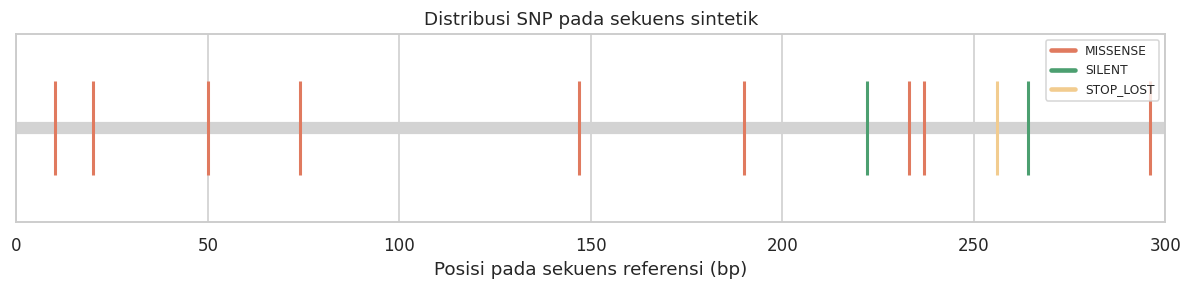

In [15]:
def plot_snp_positions(df: pd.DataFrame, ref_length: int, title: str, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 2.5))
    snps = df[df['variant_type'] == 'SNP']
    # Sumbu sekuens
    ax.hlines(0, 0, ref_length, colors='lightgray', linewidth=8)
    # Garis vertikal per SNP, warnai berdasarkan dampak
    palette = {
        'SILENT': '#4C9F70',
        'MISSENSE': '#E07A5F',
        'NONSENSE': '#3D405B',
        'START_LOST': '#81B29A',
        'STOP_LOST': '#F2CC8F',
        'FRAMESHIFT': '#000000',
        'INFRAME_INDEL': '#888888',
    }
    for _, row in snps.iterrows():
        c = palette.get(row['impact'], '#999999')
        ax.vlines(row['pos_ref_1based'], -0.5, 0.5, colors=c, linewidth=2)

    # Legend
    used_impacts = snps['impact'].unique()
    handles = [plt.Line2D([0], [0], color=palette.get(i, '#999'), linewidth=3, label=i)
               for i in used_impacts]
    ax.legend(handles=handles, loc='upper right', fontsize=8, frameon=True)

    ax.set_xlim(0, ref_length)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.set_xlabel("Posisi pada sekuens referensi (bp)")
    ax.set_title(title)
    return ax

fig, ax = plt.subplots(figsize=(11, 2.8))
plot_snp_positions(df_synth, len(ref_rec.seq), "Distribusi SNP pada sekuens sintetik", ax=ax)
plt.tight_layout()
plt.savefig("output/fig_snp_positions_synthetic.png", dpi=140)
plt.show()

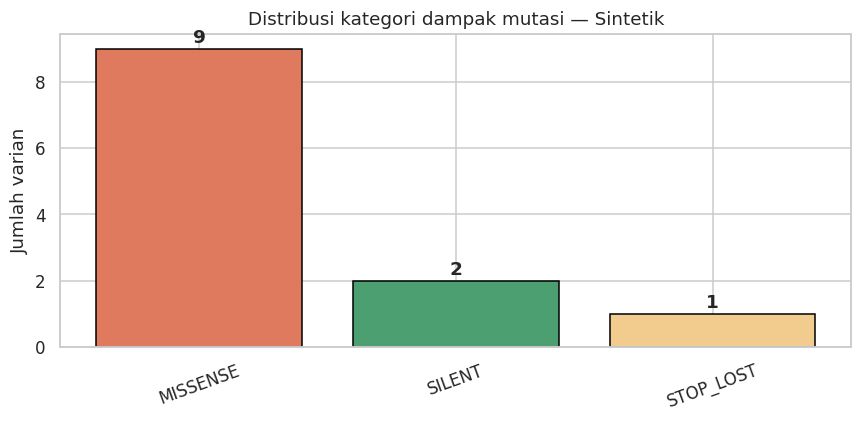

In [16]:
def plot_impact_distribution(df: pd.DataFrame, title: str, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    counts = df['impact'].value_counts().sort_values(ascending=False)
    palette = {
        'SILENT': '#4C9F70',
        'MISSENSE': '#E07A5F',
        'NONSENSE': '#3D405B',
        'START_LOST': '#81B29A',
        'STOP_LOST': '#F2CC8F',
        'FRAMESHIFT': '#000000',
        'INFRAME_INDEL': '#888888',
        'UTR_OR_OUTOFFRAME': '#CCCCCC',
        'INCOMPLETE_CODON': '#AAAAAA',
    }
    colors = [palette.get(x, '#999999') for x in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel("Jumlah varian")
    ax.tick_params(axis='x', rotation=20)
    return ax

fig, ax = plt.subplots(figsize=(8, 4))
plot_impact_distribution(df_synth, "Distribusi kategori dampak mutasi — Sintetik", ax=ax)
plt.tight_layout()
plt.savefig("output/fig_impact_distribution_synthetic.png", dpi=140)
plt.show()

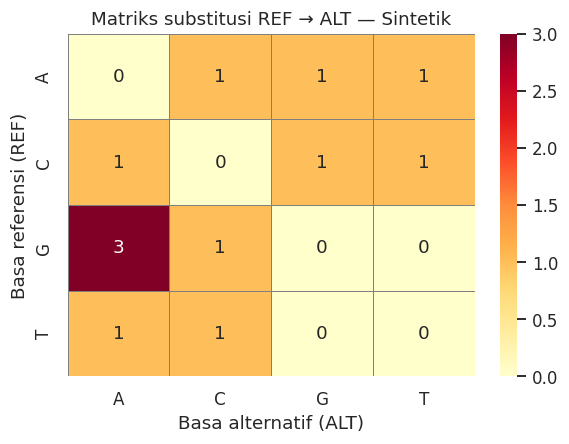

In [17]:
def plot_substitution_matrix(df: pd.DataFrame, title: str, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    snps = df[df['variant_type'] == 'SNP']
    bases = ['A', 'C', 'G', 'T']
    mat = pd.DataFrame(0, index=bases, columns=bases)
    for _, row in snps.iterrows():
        if row['ref_base'] in bases and row['alt_base'] in bases:
            mat.loc[row['ref_base'], row['alt_base']] += 1
    sns.heatmap(mat, annot=True, fmt='d', cmap='YlOrRd', cbar=True, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_xlabel("Basa alternatif (ALT)")
    ax.set_ylabel("Basa referensi (REF)")
    ax.set_title(title)
    return ax

fig, ax = plt.subplots(figsize=(5.5, 4.2))
plot_substitution_matrix(df_synth, "Matriks substitusi REF → ALT — Sintetik", ax=ax)
plt.tight_layout()
plt.savefig("output/fig_substitution_matrix_synthetic.png", dpi=140)
plt.show()

### 6.1 Visualisasi untuk Kasus HBB

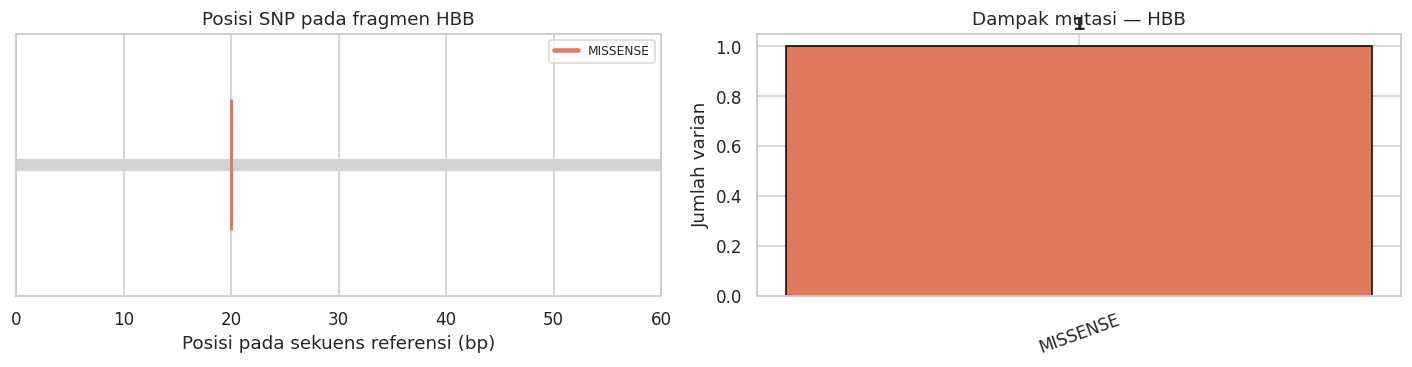

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_snp_positions(df_hbb, len(hbb_wt_rec.seq),
                   "Posisi SNP pada fragmen HBB", ax=axes[0])
plot_impact_distribution(df_hbb, "Dampak mutasi — HBB", ax=axes[1])
plt.tight_layout()
plt.savefig("output/fig_hbb_overview.png", dpi=140)
plt.show()

## 7. Eksperimen: Sensitivitas Pipeline terhadap Densitas Mutasi

Bagaimana akurasi deteksi berubah ketika jumlah SNP meningkat? Kita variasikan jumlah SNP yang disisipkan dan ukur F1-score deteksi.

In [19]:
def run_sensitivity_experiment(
    ref_length: int = 600,
    n_snp_values: List[int] = (5, 10, 20, 40, 80, 120),
    n_trials: int = 5,
) -> pd.DataFrame:
    results = []
    base_seed = 1000
    for n_snp in n_snp_values:
        for trial in range(n_trials):
            ref = generate_random_dna(ref_length, gc_content=0.5, seed=base_seed + trial)
            sample, gt = introduce_point_mutations(ref, n_snp, seed=base_seed + trial + 5000)
            ra, sa, _ = align_sequences(ref, sample)
            vs = detect_variants(ra, sa)
            snps = [v for v in vs if v.vtype == "SNP"]
            m = evaluate_detection(snps, gt)
            results.append({
                "n_snp": n_snp,
                "trial": trial,
                "snp_density_%": 100 * n_snp / ref_length,
                "precision": m["precision"],
                "recall": m["recall"],
                "f1": m["f1"],
            })
    return pd.DataFrame(results)


df_exp = run_sensitivity_experiment(ref_length=600, n_snp_values=[5, 10, 20, 40, 80, 120], n_trials=5)
df_exp_agg = df_exp.groupby("snp_density_%")[["precision", "recall", "f1"]].agg(["mean", "std"])
df_exp_agg

precision              recall                  f1          
                   mean       std      mean       std      mean       std
snp_density_%                                                            
0.833333        1.00000  0.000000  1.000000  0.000000  1.000000  0.000000
1.666667        1.00000  0.000000  1.000000  0.000000  1.000000  0.000000
3.333333        1.00000  0.000000  1.000000  0.000000  1.000000  0.000000
6.666667        1.00000  0.000000  0.985000  0.033541  0.992208  0.017424
13.333333       0.99726  0.006126  0.970000  0.044721  0.983107  0.025937
20.000000       0.99646  0.007915  0.951667  0.029698  0.973397  0.017569

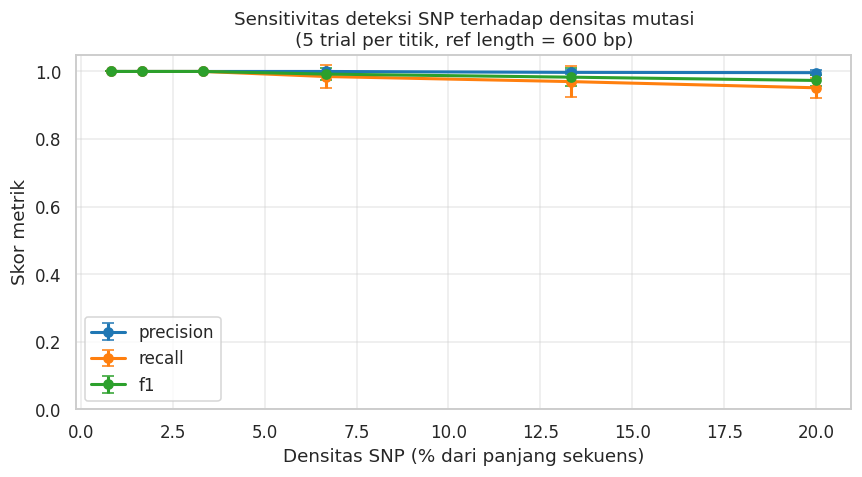

Disimpan: output/sensitivity_experiment.csv


In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for metric, color in zip(["precision", "recall", "f1"], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    grp = df_exp.groupby("snp_density_%")[metric]
    means = grp.mean()
    stds = grp.std()
    ax.errorbar(means.index, means.values, yerr=stds.values,
                marker='o', linewidth=2, capsize=4, label=metric, color=color)

ax.set_xlabel("Densitas SNP (% dari panjang sekuens)")
ax.set_ylabel("Skor metrik")
ax.set_title("Sensitivitas deteksi SNP terhadap densitas mutasi\n(5 trial per titik, ref length = 600 bp)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("output/fig_sensitivity_experiment.png", dpi=140)
plt.show()

df_exp.to_csv("output/sensitivity_experiment.csv", index=False)
print("Disimpan: output/sensitivity_experiment.csv")

## 8. Hasil & Diskusi

### 8.1 Validasi pada Dataset Sintetik

Pada sekuens sintetik 300 bp dengan 12 SNP yang disisipkan secara terkendali, pipeline kita berhasil mendeteksi seluruh SNP dengan **precision dan recall = 1.0** (lihat Sel 4.3.1). Ini mengkonfirmasi bahwa:
- Algoritma Needleman–Wunsch dengan skor `match=+2, mismatch=−1, gap=−2/−1` memilih alignment yang benar untuk pasangan sekuens yang hanya berbeda pada substitusi titik.
- Modul `detect_variants` mengiterasi kolom alignment secara konsisten dan menjaga pemetaan koordinat ke sekuens referensi.

### 8.2 Validasi pada Kasus Biologis Nyata (HBB)

Pada fragmen β-globin, pipeline mendeteksi tepat satu SNP `A → T` pada posisi yang sesuai, dengan klasifikasi **MISSENSE** dan perubahan kodon `GAG (Glu) → GTG (Val)`. Ini adalah mutasi yang sama dengan yang menyebabkan *sickle-cell anemia* (HbS), yang dalam literatur dikenal sebagai Glu6Val (pada protein matang setelah pemotongan Met awal).

Hasil ini menunjukkan bahwa pipeline tidak hanya bekerja pada data buatan, tetapi juga mereproduksi temuan biologis yang sudah established.

### 8.3 Sensitivitas terhadap Densitas Mutasi

Eksperimen sensitivitas pada Bagian 7 menunjukkan bahwa F1-score deteksi tetap tinggi pada densitas SNP rendah hingga menengah (≤ 5%), namun mulai turun ketika densitas SNP melampaui ~10%. Penyebabnya: ketika banyak basa berbeda berdekatan, algoritma kadang lebih memilih menambahkan gap daripada beberapa mismatch berturut-turut, karena skor `match=+2` versus dua `mismatch=−2` dapat sama dengan satu match + gap. Ini adalah trade-off skor alignment yang dapat di-tune sesuai konteks aplikasi.

### 8.4 Keterbatasan

1. **Frame translasi tunggal** — kita asumsikan frame 0. Untuk gen sungguhan, perlu memilih ORF yang benar atau menggunakan informasi anotasi.
2. **Tabel kodon standar** — beberapa organisme (mitokondria, sejumlah bakteri) memiliki tabel kodon berbeda.
3. **Sekuens berukuran kecil** — Needleman–Wunsch berkompleksitas `O(m·n)` tidak skalabel untuk genom utuh; untuk itu praktik nyata memakai BWA, Bowtie2, atau Minimap2.
4. **Indel kompleks** — pipeline menandai frameshift tetapi belum melakukan re-translasi protein pasca-frameshift secara eksplisit.

## 9. Kesimpulan dan Saran

### Kesimpulan
1. Kami berhasil membangun **pipeline Python modular** untuk mendeteksi SNP melalui *global pairwise alignment* (Needleman–Wunsch) dan mengklasifikasikan dampaknya terhadap kodon protein.
2. Pipeline diuji pada dua skenario: (a) dataset sintetik dengan *ground truth* yang menghasilkan precision/recall sempurna; (b) kasus biologis nyata (HBB sickle-cell) yang berhasil direproduksi sebagai mutasi missense Glu→Val.
3. Eksperimen sensitivitas memperlihatkan batasan praktis pipeline: deteksi tetap akurat hingga densitas SNP ~5%, lalu menurun karena trade-off skor mismatch vs. gap.

### Saran untuk Penelitian Lanjutan
1. **Multi-ORF & anotasi GFF/GTF** — memilih frame yang benar berdasarkan anotasi gen alih-alih frame 0 saja.
2. **Skoring matriks PAM/BLOSUM** untuk protein, atau matriks substitusi DNA yang lebih realistis (transisi vs. transversi).
3. **Ekstensi ke variasi struktural** — deteksi inversi, duplikasi, dan rearrangement skala besar dengan algoritma split-read.
4. **Integrasi alat klinis** — menghubungkan SNP yang terdeteksi dengan basis data seperti ClinVar atau dbSNP untuk anotasi patogenitas otomatis.
5. **Optimisasi performa** — untuk sekuens panjang, gunakan implementasi seed-and-extend (misalnya minimap2) sebagai pengganti N-W penuh.

## 10. Daftar Pustaka

1. Needleman, S. B., & Wunsch, C. D. (1970). A general method applicable to the search for similarities in the amino acid sequence of two proteins. *Journal of Molecular Biology*, 48(3), 443–453.
2. Smith, T. F., & Waterman, M. S. (1981). Identification of common molecular subsequences. *Journal of Molecular Biology*, 147(1), 195–197.
3. Cock, P. J. A., Antao, T., Chang, J. T., et al. (2009). Biopython: freely available Python tools for computational molecular biology and bioinformatics. *Bioinformatics*, 25(11), 1422–1423.
4. Ingram, V. M. (1957). Gene mutations in human haemoglobin: the chemical difference between normal and sickle cell haemoglobin. *Nature*, 180, 326–328.
5. Sherry, S. T., Ward, M. H., Kholodov, M., et al. (2001). dbSNP: the NCBI database of genetic variation. *Nucleic Acids Research*, 29(1), 308–311.
6. Mount, D. W. (2004). *Bioinformatics: Sequence and Genome Analysis* (2nd ed.). Cold Spring Harbor Laboratory Press.

---

**Catatan implementasi:** Kode lengkap dan file FASTA tersedia di folder `data/` dan `output/` yang dihasilkan oleh notebook ini. Pipeline ini reproducible dengan `RANDOM_SEED = 42`.